In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from imblearn.over_sampling import KMeansSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,StackingClassifier ,IsolationForest,  AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,cohen_kappa_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


In [2]:
df = pd.read_csv("Debernardi et al 2020 data.csv")
df.shape

(590, 14)

In [3]:
df.head()


,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.94884,654.282174,1262.000
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.46703,209.488250,228.407
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.36600,461.141000,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.57900,142.950000,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.54000,41.088000,NaN


In [4]:

df.describe




<bound method NDFrame.describe of     sample_id patient_cohort sample_origin  age sex  diagnosis stage  \
0          S1        Cohort1          BPTB   33   F          1   NaN   
1         S10        Cohort1          BPTB   81   F          1   NaN   
2        S100        Cohort2          BPTB   51   M          1   NaN   
3        S101        Cohort2          BPTB   61   M          1   NaN   
4        S102        Cohort2          BPTB   62   M          1   NaN   
..        ...            ...           ...  ...  ..        ...   ...   
585      S549        Cohort2          BPTB   68   M          3    IV   
586      S558        Cohort2          BPTB   71   F          3    IV   
587      S560        Cohort2          BPTB   63   M          3    IV   
588      S583        Cohort2          BPTB   75   F          3    IV   
589      S590        Cohort1          BPTB   74   M          3    IV   

    benign_sample_diagnosis  plasma_CA19_9  creatinine     LYVE1       REG1B  \
0                    

In [5]:
columns_ = df.columns.to_list()

df = df [["stage",
          "creatinine",
           "plasma_CA19_9",
          "age",
          "sex",
          "LYVE1",
          "REG1B",
          "TFF1",
          "REG1A",
          "diagnosis"]].copy()
df.sex =df.sex.map({"M":1 , "F": 0})
df.head()

,stage,creatinine,plasma_CA19_9,age,sex,LYVE1,REG1B,TFF1,REG1A,diagnosis
0,NaN,1.83222,11.7,33,0,0.893219,52.94884,654.282174,1262.000,1
1,NaN,0.97266,NaN,81,0,2.037585,94.46703,209.488250,228.407,1
2,NaN,0.78039,7.0,51,1,0.145589,102.36600,461.141000,NaN,1
3,NaN,0.70122,8.0,61,1,0.002805,60.57900,142.950000,NaN,1
4,NaN,0.21489,9.0,62,1,0.000860,65.54000,41.088000,NaN,1


In [7]:
df.isna().sum()


stage            391
creatinine         0
plasma_CA19_9    240
age                0
sex                0
LYVE1              0
REG1B              0
TFF1               0
REG1A            284
diagnosis          0
dtype: int64

In [8]:
#encoding
df['stage'] = df['stage'].fillna('Unknown')

# Step 2: Map the values
df['stage'] = df['stage'].map({
    'I': 1,
    'IA': 1,
    'IB': 1,
    'II': 2,
    'IIA': 2,
    'IIB': 2,
    'III': 3,
    'IV': 4,
    'Unknown': 0  
})


df['stage'] = df['stage'].astype(int)
print(df['stage'].unique())

[0 1 2 3 4]


In [9]:

from tabulate import tabulate

# List of feature columns
features = ['stage', 'creatinine', 'plasma_CA19_9', 'age', 'sex', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

for index, feature in enumerate(features):
    print(f"Index: {index}, Feature: {feature}")
# Group by diagnosis type
grouped = df.groupby('diagnosis')

# Calculate min, max, and mean for each feature within each diagnosis category
stats = grouped[features].agg(['min', 'max', 'mean'])

# Flatten MultiIndex columns
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]

# Reset index to turn 'diagnosis' back into a column
stats = stats.reset_index()

# Set 'diagnosis' as index to prepare for transpose
stats = stats.set_index('diagnosis')

# Transpose rows and columns
stats_t = stats.transpose()

# To make the output clearer, optionally reset index or rename columns
# For display, you might want to set 'diagnosis' as the header row
# and have features as rows, stats as columns

# Print the transposed table
print(tabulate(stats_t, headers='keys', tablefmt='grid'))

Index: 0, Feature: stage
Index: 1, Feature: creatinine
Index: 2, Feature: plasma_CA19_9
Index: 3, Feature: age
Index: 4, Feature: sex
Index: 5, Feature: LYVE1
Index: 6, Feature: REG1B
Index: 7, Feature: TFF1
Index: 8, Feature: REG1A
+--------------------+---------------+---------------+----------------+
|                    |             1 |             2 |              3 |
+====================+===============+===============+================+
| stage_min          |    0          |    0          |     1          |
+--------------------+---------------+---------------+----------------+
| stage_max          |    0          |    0          |     4          |
+--------------------+---------------+---------------+----------------+
| stage_mean         |    0          |    0          |     2.51256    |
+--------------------+---------------+---------------+----------------+
| creatinine_min     |    0.06786    |    0.05655    |     0.07917    |
+--------------------+---------------+---------

In [10]:
mean_plasma_diagnosis_1 = df.loc[df['diagnosis'] == 1, 'plasma_CA19_9'].mean()
mean_plasma_diagnosis_2 = df.loc[df['diagnosis'] == 2, 'plasma_CA19_9'].mean()
mean_plasma_diagnosis_3 =df.loc[df["diagnosis"]== 3, 'plasma_CA19_9'].mean()
df.loc[(df['diagnosis'] == 1) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_1
df.loc[(df['diagnosis'] == 2) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_2
df.loc[(df['diagnosis'] == 3) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_3
mean_reg1a_diagnosis_1 = df.loc[df['diagnosis'] == 1, 'REG1A'].mean()
mean_reg1a_diagnosis_2 = df.loc[df['diagnosis'] == 2, 'REG1A'].mean()
mean_reg1a_diagnosis_3 =df.loc[df["diagnosis"]== 3, 'REG1A'].mean()
df.loc[(df['diagnosis'] == 1) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_1
df.loc[(df['diagnosis'] == 2) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_2
df.loc[(df['diagnosis'] == 3) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_3

In [10]:
diagnosis = df.groupby("diagnosis").mean()
diagnosis.style.highlight_max()
df.isna().sum()

stage            0
creatinine       0
plasma_CA19_9    0
age              0
sex              0
LYVE1            0
REG1B            0
TFF1             0
REG1A            0
diagnosis        0
dtype: int64

In [11]:
df.describe
df.age

0      33
1      81
2      51
3      61
4      62
       ..
585    68
586    71
587    63
588    75
589    74
Name: age, Length: 590, dtype: int64

In [12]:
# Cleaning by Z-scores
from scipy import stats

z_scores = stats.zscore(df.select_dtypes(include=['float64', 'int64']))
abs_z_scores = abs(z_scores)

# Define a threshold 
threshold = 3
# Identify outliers
outliers = (abs_z_scores > threshold)

# If you want to see which rows are outliers
outlier_rows = df[(outliers).any(axis=1)]

print(outlier_rows)


# Define a threshold
threshold = 5
df_cleaned = df[(abs_z_scores < threshold).all(axis=1)]

print(df_cleaned)
df_cleaned.isna().sum()

     stage  creatinine  plasma_CA19_9  age  sex      LYVE1        REG1B  \
144      0     3.44955       8.749569   48    0   4.512589   138.798730   
210      0     1.13100       9.000000   73    1   4.860454   704.236000   
257      0     1.17624      73.000000   67    1   2.373931     9.158758   
272      0     3.33645      61.785741   31    1   0.073313    12.445650   
289      0     2.79357      20.000000   44    1   3.870352    34.417047   
317      0     1.86615      61.785741   54    0   6.913633   864.366930   
322      0     1.30065      61.785741   48    1   3.067997   459.057900   
359      0     1.00659       7.900000   40    1   1.566210   128.280180   
399      1     0.96135       0.600000   56    1   8.167554   535.281600   
408      2     0.68991    1476.154733   53    1  11.954790   682.898790   
410      2     1.05183    1476.154733   54    1  10.956950  1293.819450   
422      2     0.29406       6.000000   48    1   3.530855  1124.108000   
427      2     0.13572   

stage            0
creatinine       0
plasma_CA19_9    0
age              0
sex              0
LYVE1            0
REG1B            0
TFF1             0
REG1A            0
diagnosis        0
dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
#X , y
X = df_cleaned.drop("diagnosis", axis =1)
y = df_cleaned["diagnosis"]
# Split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(487, 9)
(487,)
(86, 9)
(86,)


In [14]:

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)
print("Original class distribution:", y_train.value_counts())
print("Resampled class distribution:", pd.Series(y_resampled).value_counts())
print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

Original class distribution: diagnosis
2    177
3    158
1    152
Name: count, dtype: int64
Resampled class distribution: diagnosis
2    177
1    170
3    165
Name: count, dtype: int64
Shape of X_resampled: (512, 9)
Shape of y_resampled: (512,)


In [15]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def sea_lion_optimizer_feature_selection(X, y, n_select=7, n_agents=20, max_iter=20, random_state=42):
    np.random.seed(random_state)
    n_features = X.shape[1]

    # Initialize the population: each agent has exactly n_select features selected
    population = np.zeros((n_agents, n_features), dtype=int)
    for i in range(n_agents):
        selected = np.random.choice(n_features, n_select, replace=False)
        population[i, selected] = 1

    # Initialize best solution
    best_solution = None
    best_fitness = -np.inf

    # Cache to avoid recomputation of fitness
    cache = {}

    # Initialize classifier
    clf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

    def fitness(solution):
        """Evaluate the fitness of a solution (subset of features)."""
        key = tuple(np.where(solution == 1)[0])
        if key in cache:
            return cache[key]
        selected_indices = np.array(key)
        if len(selected_indices) == 0:
            cache[key] = 0
            return 0
        X_subset = X.iloc[:, selected_indices]
        scores = cross_val_score(clf, X_subset, y, cv=3, scoring='accuracy')
        mean_score = scores.mean()
        cache[key] = mean_score
        return mean_score

    for iteration in range(max_iter):
        # Exploration-exploitation coefficient decreasing over iterations
        a = 2 - (2 * iteration / max_iter)  # from 2 to 0

        # Evaluate fitness for all agents
        fitness_scores = np.array([fitness(sol) for sol in population])

        # Find the best agent
        max_idx = np.argmax(fitness_scores)
        if fitness_scores[max_idx] > best_fitness:
            best_fitness = fitness_scores[max_idx]
            best_solution = population[max_idx].copy()

        # Update each agent
        for i in range(n_agents):
            current_solution = population[i]
            new_solution = current_solution.copy()

            # For each feature, probabilistically flip bits
            for j in range(n_features):
                r = np.random.rand()

                # Probability to move towards or away from best solution
                if best_solution[j] == 1:
                    # Encourage selecting feature
                    if r < 0.8:
                        new_solution[j] = 1
                    else:
                        new_solution[j] = 0
                else:
                    # Encourage deselecting feature
                    if r < 0.2:
                        new_solution[j] = 1
                    else:
                        new_solution[j] = 0

            # After updating bits, enforce exactly n_select features
            current_sum = np.sum(new_solution)
            if current_sum > n_select:
                # Deselect random features to match n_select
                ones_idx = np.where(new_solution == 1)[0]
                to_deselect = np.random.choice(ones_idx, current_sum - n_select, replace=False)
                new_solution[to_deselect] = 0
            elif current_sum < n_select:
                # Select random features to match n_select
                zeros_idx = np.where(new_solution == 0)[0]
                to_select = np.random.choice(zeros_idx, n_select - current_sum, replace=False)
                new_solution[to_select] = 1

            # Update agent
            population[i] = new_solution

    # Return indices of selected features
    selected_indices = np.where(best_solution == 1)[0]
    return selected_indices

# Usage example:
# Assuming X_resampled and y_resampled are your data
selected_indices = sea_lion_optimizer_feature_selection(X_resampled, y_resampled, n_select=7, n_agents=20, max_iter=20)

# Show selected features
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]
# Show sea lion features
print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)


Selected feature indices: [0, 1, 2, 3, 4, 7, 8]
Selected features: ['stage', 'creatinine', 'plasma_CA19_9', 'age', 'sex', 'TFF1', 'REG1A']


In [19]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def sea_lion_optimizer_feature_selection(X, y, n_select=7, n_agents=20, max_iter=20, random_state=42):
    np.random.seed(random_state)
    n_features = X.shape[1]

    # Initialize the population: binary vectors with exactly n_select features
    population = np.zeros((n_agents, n_features), dtype=int)
    for i in range(n_agents):
        selected = np.random.choice(n_features, n_select, replace=False)
        population[i, selected] = 1

    # Initialize the best solution
    best_solution = None
    best_fitness = -np.inf

    # Cache for fitness evaluations to avoid recomputation
    cache = {}

    # Define the classifier
    clf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

    def fitness(solution, cache):
        key = tuple(np.where(solution == 1)[0])
        if key in cache:
            return cache[key]
        selected_indices = np.array(key)
        if len(selected_indices) == 0:
            cache[key] = 0
            return 0
        X_subset = X.iloc[:, selected_indices]
        scores = cross_val_score(clf, X_subset, y, cv=3, scoring='accuracy')
        mean_score = scores.mean()
        cache[key] = mean_score
        return mean_score

    for iteration in range(max_iter):
        # Calculate a decreasing coefficient for exploration/exploitation balance
        a = 2 - (2 * iteration / max_iter)  # linearly decreases from 2 to 0

        # Evaluate fitness of each agent
        fitness_scores = np.array([fitness(sol, cache) for sol in population])
        max_idx = np.argmax(fitness_scores)

        # Update the best solution
        if fitness_scores[max_idx] > best_fitness:
            best_fitness = fitness_scores[max_idx]
            best_solution = population[max_idx].copy()

        # Update positions of agents
        for i in range(n_agents):
            # Generate a random coefficient for exploration/exploitation
            r1 = np.random.rand()
            r2 = np.random.rand()

            # Position update based on SLOA rules
            # Encircling prey (moving towards best solution)
            D = np.abs(r1 * best_solution - population[i])
            # The coefficient 'a' controls the size of the movement
            # For feature selection, use a probabilistic approach
            # Instead of continuous movement, update bits probabilistically
            for j in range(n_features):
                if np.random.rand() < 0.5:
                    # Move towards best
                    if best_solution[j] == 1:
                        # Keep or select feature
                        if np.random.rand() < 0.8:
                            population[i, j] = 1
                        else:
                            population[i, j] = 0
                    else:
                        # Move away from best
                        if np.random.rand() < 0.2:
                            population[i, j] = 1
                        else:
                            population[i, j] = 0
            # Maintain exactly n_select features
            current_sum = np.sum(population[i])
            if current_sum > n_select:
                # Deselect random features
                ones_idx = np.where(population[i] == 1)[0]
                to_deselect = np.random.choice(ones_idx, current_sum - n_select, replace=False)
                population[i, to_deselect] = 0
            elif current_sum < n_select:
                # Randomly select features
                zeros_idx = np.where(population[i] == 0)[0]
                to_select = np.random.choice(zeros_idx, n_select - current_sum, replace=False)
                population[i, to_select] = 1

    selected_indices = np.where(best_solution == 1)[0]
    return selected_indices
# Usage:
selected_indices = sea_lion_optimizer_feature_selection(X_resampled, y_resampled, n_select=7, n_agents=20, max_iter=20)

# Show selected features
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)




Selected feature indices: [0, 1, 2, 3, 4, 7, 8]
Selected features: ['stage', 'creatinine', 'plasma_CA19_9', 'age', 'sex', 'TFF1', 'REG1A']


In [20]:
new_X = X_resampled.iloc[:, selected_indices]
new_y = y_resampled
print(new_X.head())

   stage  creatinine  plasma_CA19_9  age  sex         TFF1        REG1A
0      0     0.61074      24.000000   56    0    19.185000   227.871886
1      2     0.09048    1476.154733   67    0   209.676000  1138.323721
2      0     3.33645      61.785741   31    1   397.911600    75.094000
3      3     1.56078    2114.000000   70    1  3210.585000  3658.172000
4      0     0.29406       5.025272   57    0     0.647148   227.871886


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:03:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Predicted probabilities shape: (77, 3)
ROC AUC: 0.9884140550807218
Results for XGBoost:
Accuracy: 0.935064935064935
Precision: 0.9479166666666666
Recall: 0.9333333333333332
F1 Score: 0.9347143753923414
Cohen's Kappa: 0.9022842639593909
Confusion Matrix:
 [[20  5  0]
 [ 0 27  0]
 [ 0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89        25
           1       0.84      1.00      0.92        27
           2       1.00      1.00      1.00        25

    accuracy                           0.94        77
   macro avg       0.95      0.93      0.93        77
weighted avg       0.95      0.94      0.93        77

--------------------------------------------------
SHAP analysis for XGBoost


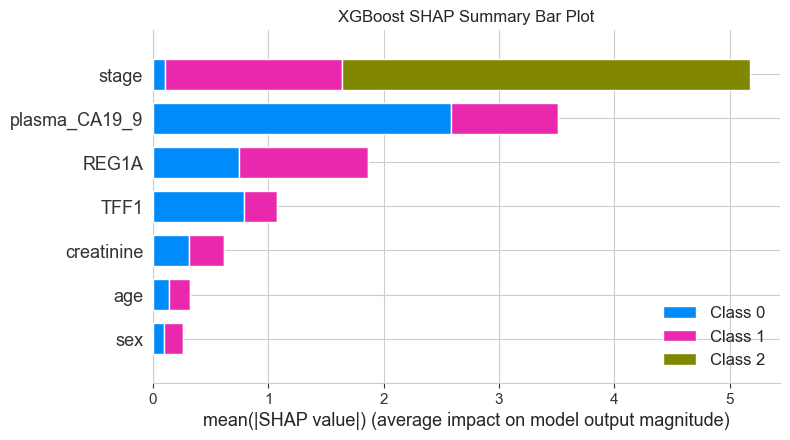

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [16]:
#xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
import shap
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Split data
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.15, random_state=42, stratify=new_y)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit only with XGBoost
xgb_model.fit(X_train, y_train_encoded)

# Evaluate the model
y_pred = xgb_model.predict(X_test)
# Get probability predictions
y_pred_proba = xgb_model.predict_proba(X_test)

# Check shape
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)
print("Results for XGBoost:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))

print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis
import matplotlib.pyplot as plt

print("SHAP analysis for XGBoost")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost SHAP Summary Bar Plot")
plt.show()


# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
import shap
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.15, random_state=42, stratify=new_y)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the parameter grid for GridSearch
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report

# Define custom scorers
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True),
    'kappa': make_scorer(cohen_kappa_score)
}

# Initialize XGBClassifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up GridSearchCV with multiple scoring metrics
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # choose the primary metric to optimize
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train_encoded)

# Get the best estimator based on ROC AUC
best_xgb_model = grid_search.best_estimator_

# Evaluate on test data with multiple metrics
y_pred = best_xgb_model.predict(X_test)
y_pred_proba = best_xgb_model.predict_proba(X_test)

print("Best parameters found: ", grid_search.best_params_)
print("ROC AUC:", roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr'))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis with best model
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost SHAP Summary Bar Plot")
plt.show()

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test)
plt.title("XGBoost SHAP Summary Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


In [ ]:
#xgb gridsearch 5 fold with
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
import shap
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.15, random_state=42, stratify=new_y)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the parameter grid for GridSearch
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report

# Define custom scorers
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True),
    'kappa': make_scorer(cohen_kappa_score)
}

# Initialize XGBClassifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up GridSearchCV with multiple scoring metrics
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # choose the primary metric to optimize
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train_encoded)

# Get the best estimator based on ROC AUC
best_xgb_model = grid_search.best_estimator_

# Evaluate on test data with multiple metrics
y_pred = best_xgb_model.predict(X_test)
y_pred_proba = best_xgb_model.predict_proba(X_test)

print("Best parameters found: ", grid_search.best_params_)
print("ROC AUC:", roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr'))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis with best model
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost SHAP Summary Bar Plot")
plt.show()


# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:04:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Predicted probabilities shape: (77, 3)
ROC AUC (multi-class OVR): 0.9884140550807218
Results for XGBoost:
Accuracy: 0.9351
Precision (macro): 0.9479
Recall (macro): 0.9333
F1 Score (macro): 0.9347
Cohen's Kappa: 0.9023
Confusion Matrix:
 [[20  5  0]
 [ 0 27  0]
 [ 0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.80      0.89        25
           2       0.84      1.00      0.92        27
           3       1.00      1.00      1.00        25

    accuracy                           0.94        77
   macro avg       0.95      0.93      0.93        77
weighted avg       0.95      0.94      0.93        77



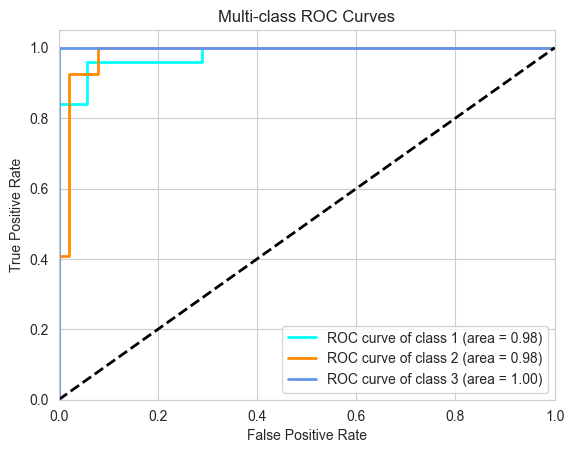

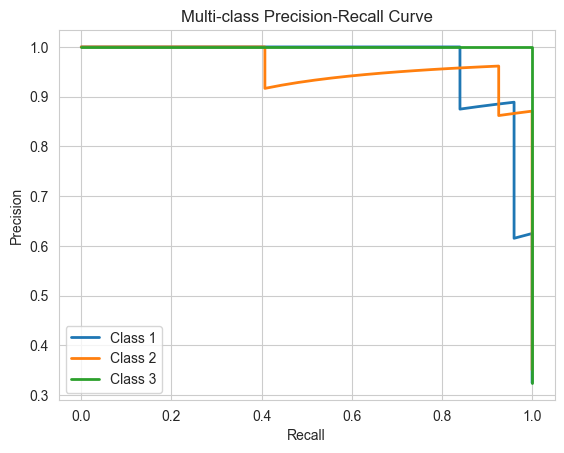

SHAP analysis for XGBoost


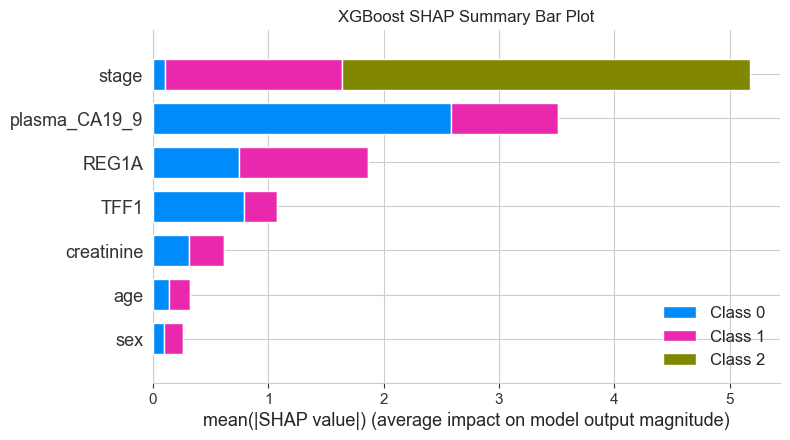

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [17]:
#xgboost with plot curve , ...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, cohen_kappa_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve
)
import shap
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Assuming new_X and new_y are already defined from your feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    new_X, new_y, test_size=0.15, random_state=42, stratify=new_y
)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit the model
xgb_model.fit(X_train, y_train_encoded)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

# Check shape
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC for multiclass
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print("ROC AUC (multi-class OVR):", roc_auc)

# Additional metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision_macro = precision_score(y_test_encoded, y_pred, average='macro')
recall_macro = recall_score(y_test_encoded, y_pred, average='macro')
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
cohen_kappa = cohen_kappa_score(y_test_encoded, y_pred)

print("Results for XGBoost:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"Cohen's Kappa: {cohen_kappa:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
target_names = list(map(str, le.classes_))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred, target_names=target_names))
# Per-class ROC Curves
n_classes = len(le.classes_)
fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded == i, y_pred_proba[:, i])
    roc_auc_per_class[i] = auc(fpr[i], tpr[i])

# Plot ROC Curves
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             lw=2, label=f'ROC curve of class {le.classes_[i]} (area = {roc_auc_per_class[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curves
plt.figure()
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_encoded == i, y_pred_proba[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {le.classes_[i]}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-class Precision-Recall Curve')
plt.legend()
plt.show()

# SHAP analysis
import shap

print("SHAP analysis for XGBoost")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost SHAP Summary Bar Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features_idx = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features_idx:
    shap.dependence_plot(feature_idx, shap_values, X_test)


Predicted probabilities shape: (77, 3)
ROC AUC: 0.9899335232668566
Results for AdaBoost:
Accuracy: 0.935064935064935
Precision: 0.9404040404040405
Recall: 0.9343209876543209
F1 Score: 0.9352992410103272
Cohen's Kappa: 0.9023833671399595
Confusion Matrix:
 [[21  4  0]
 [ 1 26  0]
 [ 0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89        25
           1       0.87      0.96      0.91        27
           2       1.00      1.00      1.00        25

    accuracy                           0.94        77
   macro avg       0.94      0.93      0.94        77
weighted avg       0.94      0.94      0.93        77

--------------------------------------------------
SHAP analysis for AdaBoost


  0%|          | 0/77 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

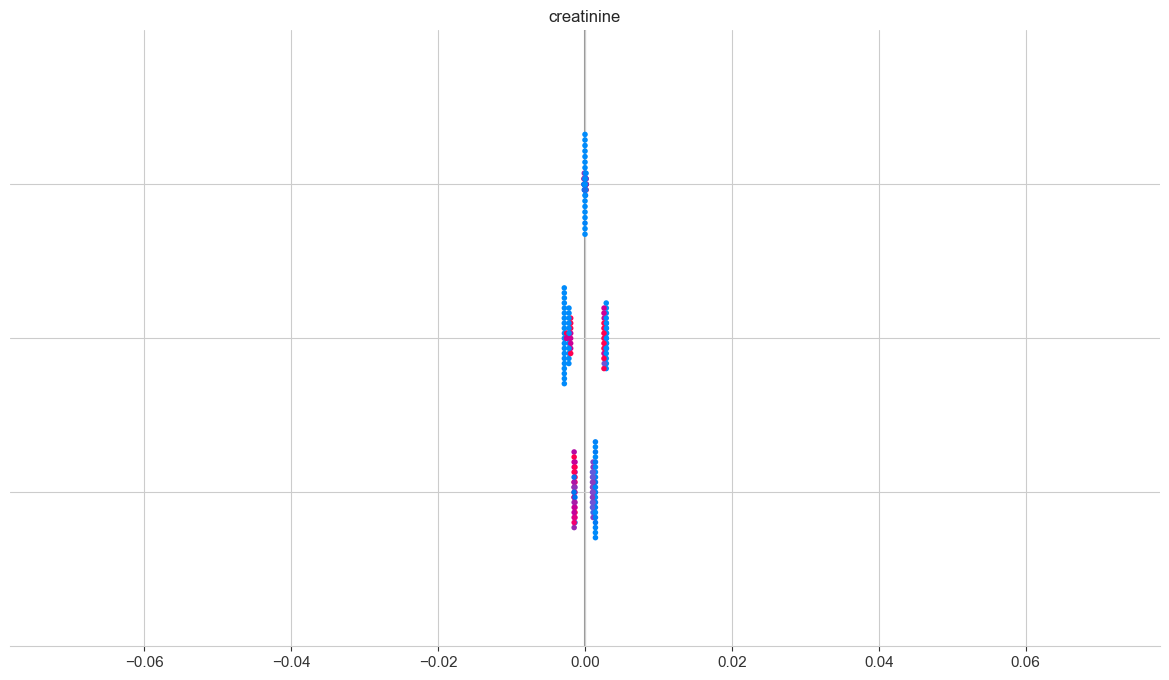

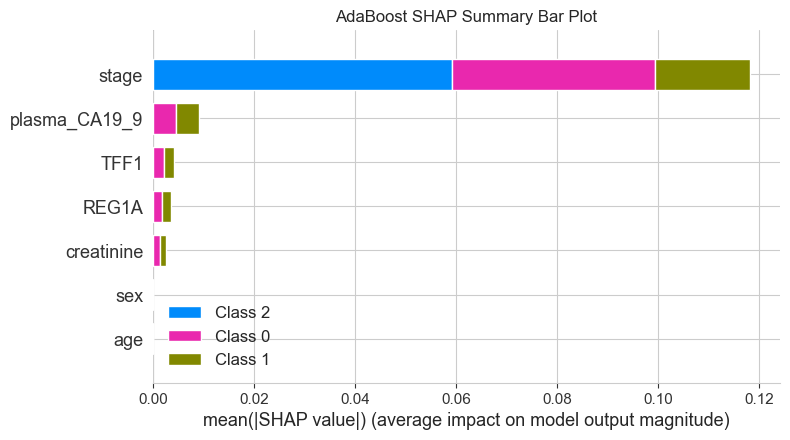

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [19]:
#adaboost
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.15, random_state=42, stratify=new_y)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize AdaBoostClassifier
ada_model = AdaBoostClassifier(
    n_estimators=100,          # You can tune this parameter
    learning_rate=1.0,         # You can tune this parameter
    random_state=42
)

# Fit the model
ada_model.fit(X_train, y_train_encoded)

# Predict on test data
y_pred = ada_model.predict(X_test)
# Get probability predictions
y_pred_proba = ada_model.predict_proba(X_test)

# Check shape of predicted probabilities
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)
print("Results for AdaBoost:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis
print("SHAP analysis for AdaBoost")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(ada_model.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_test, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("AdaBoost SHAP Summary Bar Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:50:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:50:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:50:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:50:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

ROC AUC: 0.999552856500225
Results for Stacking Ensemble:
Accuracy: 0.991304347826087
Precision: 0.991869918699187
Recall: 0.9914529914529915
F1 Score: 0.991555769333547
Cohen's Kappa: 0.9869422050641535
Confusion Matrix:
 [[40  0  0]
 [ 1 38  0]
 [ 0  0 36]]
Classification Report:
               precision    recall  f1-score   support

           1       0.98      1.00      0.99        40
           2       1.00      0.97      0.99        39
           3       1.00      1.00      1.00        36

    accuracy                           0.99       115
   macro avg       0.99      0.99      0.99       115
weighted avg       0.99      0.99      0.99       115

--------------------------------------------------
SHAP analysis for stacking_clf


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/115 [00:00<?, ?it/s]

C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have v

<Figure size 640x480 with 0 Axes>

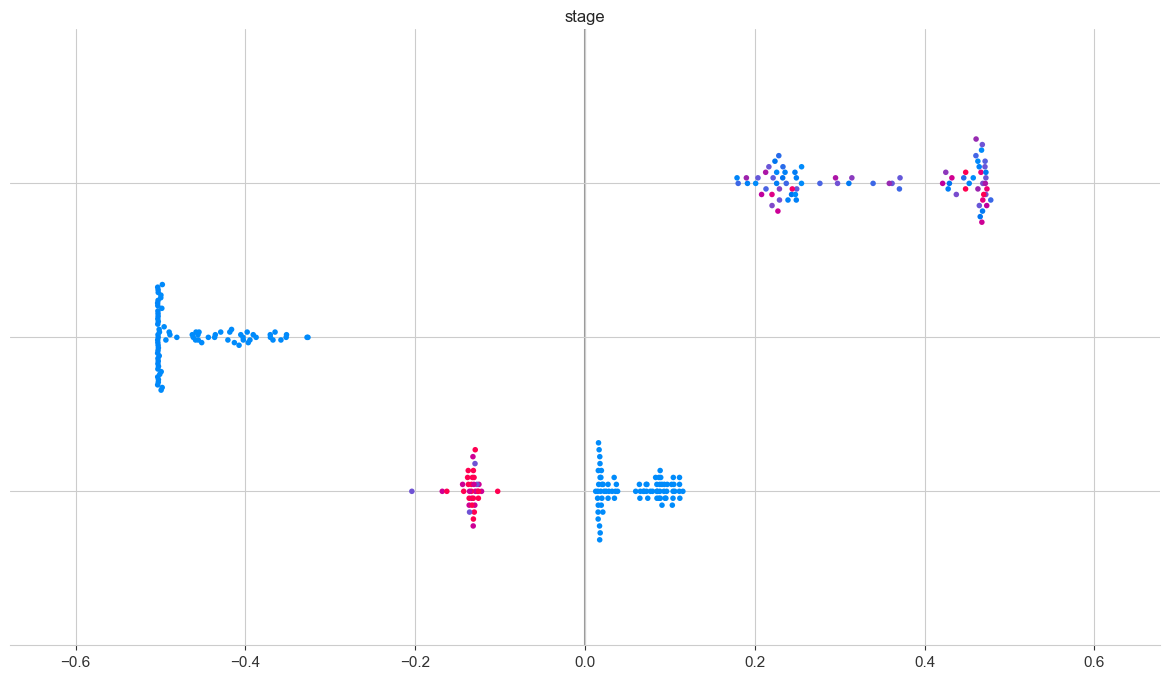

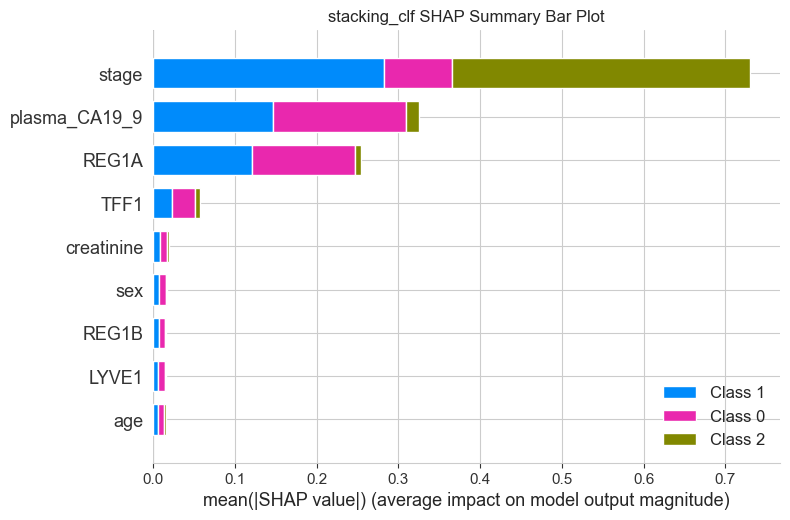

In [29]:
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb

# Assuming your data is in X and y
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize base models
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
xgboost = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('ada', adaboost),
        ('xgb', xgboost)
    ],
    final_estimator=LogisticRegression()
)

# Train ensemble
stacking_clf.fit(X_train, y_train)

# Predict on validation set
y_pred = stacking_clf.predict(X_valid)
y_pred_proba = stacking_clf.predict_proba(X_valid)

# Evaluate ROC AUC
roc_auc = roc_auc_score(y_valid, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Print metrics
print("Results for Stacking Ensemble:")
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred, average='macro'))
print("Recall:", recall_score(y_valid, y_pred, average='macro'))
print("F1 Score:", f1_score(y_valid, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification Report:\n", classification_report(y_valid, y_pred))
print("-" * 50)
# SHAP analysis
print("SHAP analysis for stacking_clf")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(stacking_clf.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_valid, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_valid)


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
plt.title("stacking_clf SHAP Summary Bar Plot")
plt.show()
